# A3 – Network Data Preparation and Generation
This notebook prepares and cleans the road and bridge data from `_roads3.csv` and `BMMS_overview.xlsx` to produce a simulation-ready CSV file for the Mesa/NetworkX network model of N1, N2, and their side roads (>25 km).

In [1]:
import pandas as pd
import numpy as np
import math
import re
import matplotlib.pyplot as plt

# Load the two source files
road_data = pd.read_csv('../data/_roads3.csv')
bridge_data = pd.read_excel('../data/BMMS_overview.xlsx')

print(f"_roads3.csv:        {road_data.shape[0]} rows, {road_data.shape[1]} columns")
print(f"BMMS_overview.xlsx: {bridge_data.shape[0]} rows, {bridge_data.shape[1]} columns")
print(f"\n _roads3.csv columns\n{list(road_data.columns)}")
print(f"\n BMMS_overview.xlsx columns\n{list(bridge_data.columns)}")
print(f"\n _roads3.csv 'type' values\n{road_data['type'].value_counts().head(15)}")
print(f"\n _roads3.csv sample rows")
road_data.head(10)

_roads3.csv:        51348 rows, 8 columns
BMMS_overview.xlsx: 20415 rows, 20 columns

 _roads3.csv columns
['road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name']

 BMMS_overview.xlsx columns
['road', 'km', 'type', 'LRPName', 'name', 'length', 'condition', 'structureNr', 'roadName', 'chainage', 'width', 'constructionYear', 'spans', 'zone', 'circle', 'division', 'sub-division', 'lat', 'lon', 'EstimatedLoc']

 _roads3.csv 'type' values
type
KmPost               19467
Culvert              17542
Bridge                8933
Others                2472
SideRoad,Right         628
SideRoad,Left          613
RailRoadCrossing       320
CrossRoad              296
Turnoff,Right          202
Turnoff,Left           168
Others / Others        123
Bridge / Bridge        103
Culvert / Culvert       67
Monument                64
KmPost / KmPost         63
Name: count, dtype: int64

 _roads3.csv sample rows


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing
5,N1,2.130,LRP002a,23.697361,90.461667,NaN,Culvert,Box culvert
6,N1,3.000,LRP003,23.693833,90.469138,NaN,KmPost,Km post missing
7,N1,4.000,LRP004,23.693611,90.478777,NaN,KmPost,Km post missing
8,N1,4.175,LRP004a,23.693805,90.480527,NaN,"SideRoad,Right",Road to Narayanganj(R111)
9,N1,5.000,LRP005,23.694750,90.488500,NaN,KmPost,Km post missing


In [2]:
import math
import re

# Regex that matches N-road names including those with a space (e.g. "N 2", "N 208")
N_ROAD_PATTERN = re.compile(r'\bN\s?\d{1,3}\b')


def extract_nroads(text):
    """Extract N-road names from text, normalizing 'N 2' -> 'N2', 'N 208' -> 'N208'."""
    return {m.replace(' ', '') for m in N_ROAD_PATTERN.findall(str(text))}


# ── Helpers ───────────────────────────────────────────────────────

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/lon points in **meters** (Haversine)."""
    R = 6_371_000  # Earth's radius in metres
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def is_within_distance(lat1, lon1, lat2, lon2, x):
    """Return True if two geographic points are within *x* meters of each other."""
    return haversine_distance(lat1, lon1, lat2, lon2) <= x


def find_nearest_bridge_on_road(lat, lon, bridge_df, road_name):
    """Return (nearest_row, distance_m) for the closest BMMS bridge on *road_name*."""
    road_bridges = bridge_df[bridge_df['road'] == road_name]
    min_dist = float('inf')
    nearest = None
    for _, row in road_bridges.iterrows():
        d = haversine_distance(lat, lon, row['lat'], row['lon'])
        if d < min_dist:
            min_dist = d
            nearest = row
    return nearest, min_dist


def get_all_bridges_at_crossing(bridge_record, bridge_df):
    """Return list of all bridge records at the same crossing (same road & chainage)."""
    same_crossing = bridge_df[
        (bridge_df['road'] == bridge_record['road']) &
        (bridge_df['chainage'] == bridge_record['chainage'])
    ]
    return [row.to_dict() for _, row in same_crossing.iterrows()]


# ── Side-road identification ─────────────────────────────────────

def identify_intersecting_sideroads(road_df):
    """
    Identify all N-type side roads that intersect with N1 and N2.
    Returns a sorted list of unique road names (e.g. ['N101', 'N105', ...]).
    """
    main_roads = {'N1', 'N2'}
    sideroads = set()

    for _, row in road_df.iterrows():
        row_type = str(row['type']).strip() if pd.notna(row['type']) else ''
        if not any(t in row_type for t in ['SideRoad', 'CrossRoad', 'Others']):
            continue

        roads_in_road = extract_nroads(row['road'])
        roads_in_name = extract_nroads(row['name'])

        if roads_in_road & main_roads:
            sideroads.update(roads_in_name - main_roads)
        if roads_in_name & main_roads:
            sideroads.update(roads_in_road - main_roads)

    return sorted(sideroads, key=lambda x: (len(x), x))


def filter_roads_by_minimum_length(road_list, road_df, min_km=25):
    """Keep only roads whose maximum chainage exceeds *min_km* kilometres."""
    filtered = []
    for road in road_list:
        road_rows = road_df[road_df['road'] == road]
        if road_rows.empty:
            continue
        max_chainage = road_rows['chainage'].max()
        if max_chainage > min_km:
            filtered.append(road)
        else:
            print(f"  Removed {road}: max chainage {max_chainage:.1f} km <= {min_km} km")
    return filtered


def add_missing_sideroads(road_list):
    """Manually add side roads not found by identify_intersecting_sideroads."""
    missing = ['N106']
    for road in missing:
        if road not in road_list:
            road_list.append(road)
            print(f"  Manually added missing side road: {road}")
    return road_list


# ── Intersection post-processing ─────────────────────────────────

def unify_intersection_identifiers(df_road_file, merge_threshold_m=500):
    """
    Pair matching intersection rows and assign them the same ID.

    Two rows are paired when one's 'road' appears in the other's 'name'
    and they are within *merge_threshold_m* metres of each other.

    Threshold rationale: the two paired rows (e.g. N1's record of 'crosses N2'
    and N2's record of 'crosses N1') represent the same physical point. The
    500 m threshold accommodates typical GPS and chainage rounding errors in
    _roads3.csv (~100-300 m) while being tight enough to never accidentally
    merge two distinct intersections, which are always several kilometres apart
    on Bangladesh's national road network.
    """
    intersections = df_road_file[df_road_file['model_type'] == 'intersection'].copy()
    if intersections.empty:
        return df_road_file

    int_info = []
    for idx, row in intersections.iterrows():
        road = str(row['road']).strip()
        refs = extract_nroads(row['name'])
        int_info.append((idx, road, refs, row['lat'], row['lon'], row['id']))

    pairs = []
    for i in range(len(int_info)):
        for j in range(i + 1, len(int_info)):
            idx_a, road_a, refs_a, lat_a, lon_a, id_a = int_info[i]
            idx_b, road_b, refs_b, lat_b, lon_b, id_b = int_info[j]
            if road_b in refs_a or road_a in refs_b:
                dist = haversine_distance(lat_a, lon_a, lat_b, lon_b)
                if dist <= merge_threshold_m:
                    shared_id = min(id_a, id_b)
                    df_road_file.at[idx_a, 'id'] = shared_id
                    df_road_file.at[idx_b, 'id'] = shared_id
                    pairs.append((road_a, road_b, shared_id, dist))

    print(f"  Unified {len(pairs)} intersection pairs (threshold: {merge_threshold_m} m)")
    for road_a, road_b, sid, dist in pairs:
        print(f"    {road_a} <-> {road_b}: id={sid}, distance={dist:.0f} m")
    return df_road_file


def handle_intersection_edge_cases(df_road_file, road_list):
    """
    Manually inject intersection rows for edge cases not caught by the main loop:
      1. sourcesink rows that also serve as intersections (detected via name column)
      2. N1-N106: no cross-reference exists in _roads3.csv
      3. N104-N1: N104's LRPS references 'Z1031' instead of 'N1'
    """
    rows_to_insert = []
    next_id = int(df_road_file['id'].max()) + 1

    # Category 1: sourcesink rows that are also intersections
    sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
    for idx, row in sourcesinks.iterrows():
        name = str(row['name']) if pd.notna(row['name']) else ''
        road = str(row['road']).strip()
        refs = extract_nroads(name) - {road}
        matching = refs & set(road_list)
        if matching:
            for ref_road in matching:
                rows_to_insert.append({
                    'road': road, 'id': next_id, 'model_type': 'intersection',
                    'name': f'Intersection {road}-{ref_road}',
                    'lat': row['lat'], 'lon': row['lon'],
                    'length': np.nan, 'condition': '', 'lrp': row.get('lrp', '')
                })
                print(f"  Edge case: {road} sourcesink is also intersection with {ref_road} (id={next_id})")
                next_id += 1

    # Category 2: Missing N1-N106 intersection (no cross-reference in _roads3.csv)
    if 'N106' in road_list and 'N1' in road_list:
        existing = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N1') &
            (df_road_file['name'].str.contains('N106', na=False))
        ]
        if existing.empty:
            rows_to_insert.append({
                'road': 'N1', 'id': next_id, 'model_type': 'intersection',
                'name': 'Intersection N1-N106 (manual)',
                'lat': 23.461, 'lon': 91.175,
                'length': np.nan, 'condition': '', 'lrp': ''
            })
            print(f"  Edge case: Added missing N1-N106 intersection on N1 (id={next_id})")
            n1_n106_id = next_id
            next_id += 1
            rows_to_insert.append({
                'road': 'N106', 'id': n1_n106_id, 'model_type': 'intersection',
                'name': 'Intersection N106-N1 (manual)',
                'lat': 23.461, 'lon': 91.175,
                'length': np.nan, 'condition': '', 'lrp': ''
            })
            print(f"  Edge case: Added missing N106-N1 intersection on N106 (id={n1_n106_id})")

    # Category 3: N104-N1 intersection (N104 LRPS references 'Z1031' instead of 'N1')
    if 'N104' in road_list and 'N1' in road_list:
        existing_n104 = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N104') &
            (df_road_file['name'].str.contains('N1', na=False))
        ]
        if existing_n104.empty:
            rows_to_insert.append({
                'road': 'N104', 'id': next_id, 'model_type': 'intersection',
                'name': 'Intersection N104-N1 (manual)',
                'lat': 23.0096667, 'lon': 91.3994163,
                'length': np.nan, 'condition': '', 'lrp': ''
            })
            print(f"  Edge case: Added missing N104-N1 intersection on N104 (id={next_id})")
            next_id += 1

    if rows_to_insert:
        df_road_file = pd.concat([df_road_file, pd.DataFrame(rows_to_insert)], ignore_index=True)
        print(f"  Total edge-case rows added: {len(rows_to_insert)}")
    return df_road_file


def align_n1_n2_intersection_ids(df_road_file):
    """Ensure the N1-N2 intersection pair shares the same (lower) ID."""
    n1_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N1') &
        (df_road_file['name'].str.contains('N2', na=False))
    ]
    n2_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N2') &
        (df_road_file['name'].str.contains('N1', na=False))
    ]
    if not n1_int.empty and not n2_int.empty:
        shared_id = min(n1_int.iloc[0]['id'], n2_int.iloc[0]['id'])
        df_road_file.loc[n1_int.index, 'id'] = shared_id
        df_road_file.loc[n2_int.index, 'id'] = shared_id
        print(f"  Aligned N1-N2 intersection IDs to {shared_id}")
    else:
        print("  Warning: could not find both N1-N2 intersection entries")
    return df_road_file


# ── Distance computation ─────────────────────────────────────────

def compute_inter_node_distances(df_road_file):
    """
    Fill NaN lengths by computing the Haversine distance to the preceding row.
    Processes each road separately; the first entry of each road gets length 0.
    """
    df = df_road_file.copy()
    for road in df['road'].unique():
        road_indices = df.index[df['road'] == road]
        for pos, idx in enumerate(road_indices):
            if pd.isna(df.at[idx, 'length']):
                if pos == 0:
                    df.at[idx, 'length'] = 0
                else:
                    prev_idx = road_indices[pos - 1]
                    d = haversine_distance(
                        df.at[prev_idx, 'lat'], df.at[prev_idx, 'lon'],
                        df.at[idx, 'lat'], df.at[idx, 'lon']
                    )
                    df.at[idx, 'length'] = round(d)
    df['length'] = df['length'].round().astype(int)
    return df


# ── Build Simulation Network ──────────────────

def build_simulation_network(road_df, bridge_df, main_roads=None):
    """
    Build a simulation-ready dataframe from _roads3.csv and BMMS_overview.xlsx.

    Steps:
      1. Identify intersecting N-type side roads for N1 and N2.
      2. Filter side roads to those > 25 km.
      3. Add manually missing side roads.
      4. Process every road: classify each row as sourcesink, link, bridge,
         or intersection and collect structured entries.

    Returns (df_road_file, road_list).
    """
    if main_roads is None:
        main_roads = ['N1', 'N2']

    print("Step 1: Identifying intersecting side roads ...")
    sideroads = identify_intersecting_sideroads(road_df)
    print(f"  Found {len(sideroads)} candidate side roads: {sideroads}")

    print("\nStep 2: Filtering roads by 25 km minimum length ...")
    sideroads = filter_roads_by_minimum_length(sideroads, road_df, min_km=25)
    print(f"  {len(sideroads)} side roads after filtering: {sideroads}")

    print("\nStep 3: Adding manually missing side roads ...")
    sideroads = add_missing_sideroads(sideroads)

    road_list = main_roads + sideroads
    print(f"\nFull road list ({len(road_list)} roads): {road_list}")

    print("\nStep 4: Processing roads ...")
    entries = []
    id_counter = {}
    for idx, road in enumerate(road_list):
        id_counter[road] = (idx + 1) * 1_000_000

    for road_name in road_list:
        rd = road_df[road_df['road'] == road_name].reset_index(drop=True)
        if rd.empty:
            print(f"  Warning: no data for road '{road_name}', skipping.")
            continue

        cid = id_counter[road_name]
        link_n = bridge_n = intersection_n = 0

        def next_id():
            nonlocal cid
            current = cid
            cid += 1
            return current

        def add_entry(model_type, name, lat, lon, length, condition='', lrp=''):
            entries.append(dict(
                road=road_name, id=next_id(), model_type=model_type,
                name=name, lat=lat, lon=lon,
                length=length, condition=condition, lrp=lrp,
            ))

        i = 0
        while i < len(rd):
            s = rd.iloc[i]
            stype = str(s['type']).strip() if pd.notna(s['type']) else ''
            sgap = str(s['gap']).strip() if pd.notna(s['gap']) else ''
            slrp = str(s['lrp']).strip() if pd.notna(s['lrp']) else ''
            sname = str(s['name']).strip() if pd.notna(s['name']) else ''

            # ═══ Road Start (LRPS) → sourcesink ═══
            if slrp == 'LRPS' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], 0.0, lrp=slrp)
                i += 1

            # ═══ Road End (LRPE) → sourcesink ═══
            elif slrp == 'LRPE' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Culvert ═══
            elif 'Culvert' in stype:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                nearest, dist = find_nearest_bridge_on_road(
                    s['lat'], s['lon'], bridge_df, road_name)
                if nearest is not None and dist <= 50:
                    all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                    bridge_n += 1
                    blen = nearest['length'] if pd.notna(nearest['length']) else 0
                    bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                    bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else f'bridge {bridge_n}'
                    if len(all_bridges) > 1:
                        bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    add_entry('bridge', bname, s['lat'], s['lon'], blen, bcond, lrp=slrp)
                i += 1

            # ═══ Bridge (BS/BE) ═══
            elif 'Bridge' in stype:
                if sgap == 'BS':
                    bs_lat, bs_lon = s['lat'], s['lon']
                    link_n += 1
                    add_entry('link', f'link {link_n}', bs_lat, bs_lon, np.nan, lrp=slrp)

                    be_lat = be_lon = be_lrp = None
                    if (i + 1 < len(rd)
                            and str(rd.iloc[i + 1]['gap']).strip() == 'BE'):
                        nxt = rd.iloc[i + 1]
                        be_lat, be_lon = nxt['lat'], nxt['lon']
                        be_lrp = str(nxt['lrp']).strip()

                    if be_lat is not None:
                        blat = (bs_lat + be_lat) / 2
                        blon = (bs_lon + be_lon) / 2
                    else:
                        blat, blon = bs_lat, bs_lon

                    nearest, dist = find_nearest_bridge_on_road(
                        blat, blon, bridge_df, road_name)
                    bridge_n += 1

                    if nearest is not None and dist <= 200:
                        all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                        blen = nearest['length'] if pd.notna(nearest['length']) else 0
                        bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                        bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else sname
                        if len(all_bridges) > 1:
                            bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    else:
                        blen, bcond = 0, 'B'
                        bname = sname if sname else f'bridge {bridge_n} (dummy)'

                    add_entry('bridge', bname, blat, blon, blen, bcond, lrp=slrp)

                    if be_lat is not None:
                        link_n += 1
                        add_entry('link', f'link {link_n}', be_lat, be_lon, 0, lrp=be_lrp)
                        i += 2
                    else:
                        i += 1
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                    i += 1

            # ═══ Intersection detection (CrossRoad / SideRoad) ═══
            elif any(t in stype for t in ['CrossRoad', 'SideRoad']):
                road_refs = extract_nroads(sname)
                road_col_refs = extract_nroads(s['road'])
                matching_roads = ((road_refs | road_col_refs) - {road_name}) & set(road_list)
                if matching_roads:
                    intersection_n += 1
                    add_entry('intersection', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Default → link ═══
            else:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

        print(f"  {road_name}: {link_n} links, {bridge_n} bridges, "
              f"{intersection_n} intersections, {cid - id_counter[road_name]} total entries")

    df_road_file = pd.DataFrame(entries)
    return df_road_file, road_list


# ── Execute ──────────────────────────────────────────────────────

print('Building simulation network ...')
df_road_file, road_list = build_simulation_network(road_data, bridge_data)

print('\nHandling intersection edge cases ...')
df_road_file = handle_intersection_edge_cases(df_road_file, road_list)

print('\nUnifying intersection identifiers ...')
df_road_file = unify_intersection_identifiers(df_road_file)

print('\nAligning N1-N2 intersection IDs ...')
df_road_file = align_n1_n2_intersection_ids(df_road_file)

print('\nComputing inter-node distances ...')
df_road_file = compute_inter_node_distances(df_road_file)

# Save
save_path = '../data/network_data.csv'
df_road_file.to_csv(save_path, index=False)
print(f'\nSaved  {save_path}  ({df_road_file.shape[0]} rows x {df_road_file.shape[1]} cols)')
print(f'\nmodel_type breakdown:\n{df_road_file["model_type"].value_counts().to_string()}')
print(f'\nRoads included: {df_road_file["road"].unique().tolist()}')
df_road_file

Building simulation network ...
Step 1: Identifying intersecting side roads ...
  Found 22 candidate side roads: ['N102', 'N104', 'N105', 'N107', 'N108', 'N109', 'N110', 'N111', 'N112', 'N119', 'N120', 'N123', 'N128', 'N129', 'N203', 'N204', 'N205', 'N206', 'N207', 'N208', 'N209', 'N210']

Step 2: Filtering roads by 25 km minimum length ...
  Removed N107: max chainage 10.5 km <= 25 km
  Removed N108: max chainage 22.5 km <= 25 km
  Removed N109: max chainage 2.5 km <= 25 km
  Removed N110: max chainage 7.6 km <= 25 km
  Removed N111: max chainage 12.7 km <= 25 km
  Removed N112: max chainage 2.7 km <= 25 km
  Removed N119: max chainage 2.4 km <= 25 km
  Removed N120: max chainage 20.9 km <= 25 km
  Removed N123: max chainage 8.1 km <= 25 km
  Removed N128: max chainage 1.3 km <= 25 km
  Removed N129: max chainage 2.8 km <= 25 km
  Removed N203: max chainage 1.0 km <= 25 km
  Removed N205: max chainage 2.5 km <= 25 km
  Removed N206: max chainage 1.8 km <= 25 km
  Removed N209: max cha

,road,id,model_type,name,lat,lon,length,condition,lrp
0,N1,1000000,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,,LRPS
1,N1,1000001,link,link 1,23.702917,90.450417,800,,LRPSa
2,N1,1000002,link,link 2,23.702778,90.450472,16,,LRPSb
3,N1,1000003,link,link 3,23.702139,90.451972,168,,LRP001
4,N1,1000004,link,link 4,23.697889,90.460583,996,,LRP002
...,...,...,...,...,...,...,...,...,...
4077,N208,7000145,intersection,Intersection N208-N207,24.471360,91.765556,46509,,LRPS
4078,N208,2000907,intersection,Intersection N208-N2,24.877555,91.875360,46509,,LRPE
4079,N1,9000271,intersection,Intersection N1-N106 (manual),23.461000,91.175000,311179,,
4080,N106,9000271,intersection,Intersection N106-N1 (manual),23.461000,91.175000,138560,,


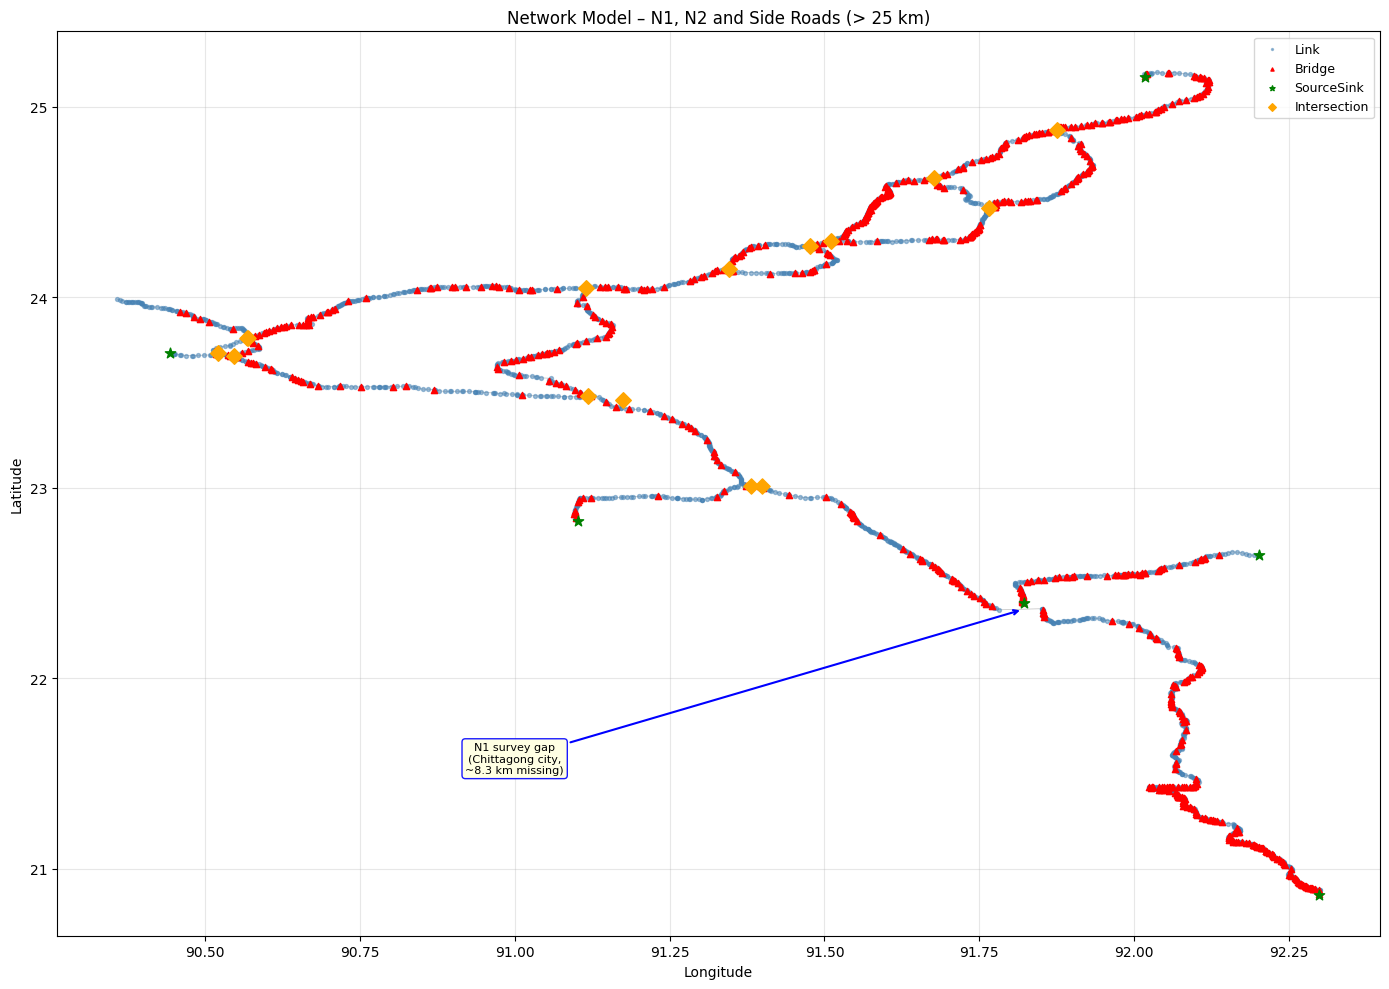


Summary: 17 sourcesinks, 26 intersections, 737 bridges, 3302 links


In [6]:
# Visualize the generated network
bridges = df_road_file[df_road_file['model_type'] == 'bridge']
links = df_road_file[df_road_file['model_type'] == 'link']
sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
intersections = df_road_file[df_road_file['model_type'] == 'intersection']

plt.figure(figsize=(14, 10))

# Draw road backbone through links, bridges, and sourcesinks only.
# Intersection nodes are excluded because CrossRoad/SideRoad rows in _roads3.csv
# can have coordinates slightly off the road centreline.
for road in df_road_file['road'].unique():
    rd = df_road_file[
        (df_road_file['road'] == road) &
        (df_road_file['model_type'].isin(['link', 'bridge', 'sourcesink'])) &
        (df_road_file['lrp'] != '')
    ]
    plt.plot(rd['lon'], rd['lat'], linewidth=0.5, color='grey', alpha=0.5)

plt.scatter(links['lon'], links['lat'], s=8, color='steelblue', label='Link', zorder=2, alpha=0.5)
plt.scatter(bridges['lon'], bridges['lat'], s=20, color='red', marker='^', label='Bridge', zorder=3)
plt.scatter(sourcesinks['lon'], sourcesinks['lat'], s=60, color='green', marker='*', label='SourceSink', zorder=4)
plt.scatter(intersections['lon'], intersections['lat'], s=60, color='orange', marker='D', label='Intersection', zorder=5)

# Annotate the Chittagong city survey gap on N1
# The survey data has an ~8.3 km gap through Chittagong city (chainage 232.7-241.1 km),
# causing a straight diagonal line that looks like a road crossing but is just N1 itself.
gap_lat, gap_lon = 22.36, 91.82
plt.annotate(
    'N1 survey gap\n(Chittagong city,\n~8.3 km missing)',
    xy=(gap_lon, gap_lat),
    xytext=(91.0, 21.5),
    fontsize=8,
    ha='center',
    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='blue', alpha=0.9),
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Network Model – N1, N2 and Side Roads (> 25 km)')
plt.legend(markerscale=0.5, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary: {len(sourcesinks)} sourcesinks, {len(intersections)} intersections, "
      f"{len(bridges)} bridges, {len(links)} links")

# Bonus Assignment

In [4]:
'''todoooo'''

'todoooo'